### Machine Learning in Python

#### There are many Machine (and Deep) learning frameworks in the python ecosystem
and the choice depends on the data you have, and the task you want to tackle.
TensorFlow is the leading Deep Learning framework. Other widely popular frameworks include Keras, Caffe, and PyTorch. 


Scikit-learn is a widely used machine learning library for Python. While it is not specifically designed for deep learning, it offers a wide range of classical machine learning algorithms, such as SVMs, decision trees, and random forests. Scikit-learn is well-documented, easy to use, and serves as a great starting point for those new to machine learning.

# Scikit-learn at a Glance

 Scikit-learn is a popular and widely used machine learning library for Python. 
 - It is built on top of other scientific libraries such as NumPy and SciPy, making it easy to integrate with the Python data science ecosystem. 
 -  It includes supervised learning algorithms such as linear regression, logistic regression, support vector machines (SVM), decision trees, random forests, and more. Additionally, it offers unsupervised learning algorithms like clustering (K-means, DBSCAN) and dimensionality reduction techniques (PCA, t-SNE).
 - It provides a wide range of tools for data preprocessing and feature engineering. It includes functionalities for handling missing values, feature scaling, one-hot encoding, and more.
 - It offers various metrics for evaluating the performance of machine learning models, and provides utilities for cross-validation, hyperparameter tuning, and model selection.
 - It is well-integrated with other Python data science libraries, such as Pandas, for data manipulation and Seaborn/Matplotlib for data visualization.

<img src="figures/imgs/scikit-learn-cheatsheet.png" width="80%" />

---

### Training a Machine Learning model

Now, let's have a look at how the training and testing of a supervised learning model works:
- Feed **training data** (X) and **training labels** (y) into the model; 


Once the model is trained:
- Make predictions using the test data; 
- Evaluate the performance using test labels.

<img src="./figures/imgs/supervised_workflow.svg" width="60%" style="background: #4682B4">


## 🏠 Example 1: Predicting House Prices (Regression)

We’ll predict house prices based on the size (square footage). This is an example of **supervised learning** using **linear regression**.

We’ll use scikit-learn, a simple and powerful machine learning library.

We'll use the California housing dataset available in scikit-learn.
It contains data about districts in California, such as average number of rooms,population, income, and median house value.


In [1]:

from sklearn.datasets import fetch_california_housing
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_squared_error, r2_score
import pandas as pd
import matplotlib.pyplot as plt

# Load the dataset
housing = fetch_california_housing(as_frame=True)
df = housing.frame

# Display a preview
df.head()


,MedInc,HouseAge,AveRooms,AveBedrms,Population,AveOccup,Latitude,Longitude,MedHouseVal
0,8.3252,41.0,6.984127,1.023810,322.0,2.555556,37.88,-122.23,4.526
1,8.3014,21.0,6.238137,0.971880,2401.0,2.109842,37.86,-122.22,3.585
2,7.2574,52.0,8.288136,1.073446,496.0,2.802260,37.85,-122.24,3.521
3,5.6431,52.0,5.817352,1.073059,558.0,2.547945,37.85,-122.25,3.413
4,3.8462,52.0,6.281853,1.081081,565.0,2.181467,37.85,-122.25,3.422


R² score: 0.013795337532284901
Mean Squared Error: 1.2923314440807299


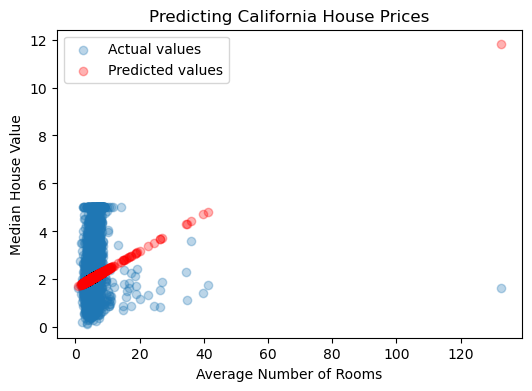

In [2]:
# Let's select one feature (average number of rooms) to predict the target (median house value)
X = df[['AveRooms']]
y = df['MedHouseVal']

# Split data into training and test sets
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

# Train a simple Linear Regression model
model = LinearRegression()
model.fit(X_train, y_train)

# Make predictions
y_pred = model.predict(X_test)

# Evaluate performance
print("R² score:", r2_score(y_test, y_pred))
print("Mean Squared Error:", mean_squared_error(y_test, y_pred))

# Visualize the regression line
plt.figure(figsize=(6,4))
plt.scatter(X_test, y_test, alpha=0.3, label="Actual values")
plt.scatter(X_test, y_pred, color="red", alpha=0.3, label="Predicted values")
plt.xlabel("Average Number of Rooms")
plt.ylabel("Median House Value")
plt.title("Predicting California House Prices")
plt.legend()
plt.show()


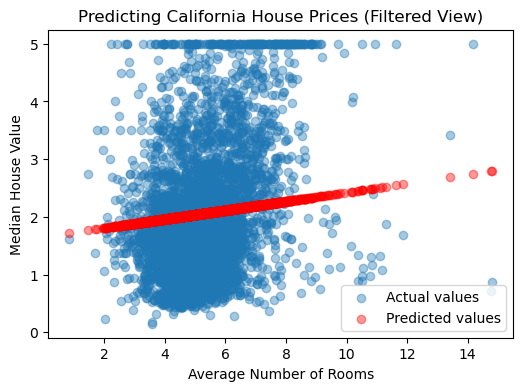

In [3]:
# Filter out extreme outliers for visualization (e.g., average rooms < 15)
mask = X_test['AveRooms'] < 15
X_vis = X_test[mask]
y_vis = y_test[mask]
y_pred_vis = y_pred[mask]

plt.figure(figsize=(6,4))
plt.scatter(X_vis, y_vis, alpha=0.4, label="Actual values")
plt.scatter(X_vis, y_pred_vis, color="red", alpha=0.4, label="Predicted values")
plt.xlabel("Average Number of Rooms")
plt.ylabel("Median House Value")
plt.title("Predicting California House Prices (Filtered View)")
plt.legend()
plt.show()


R² score: 0.459
Mean Squared Error: 0.709


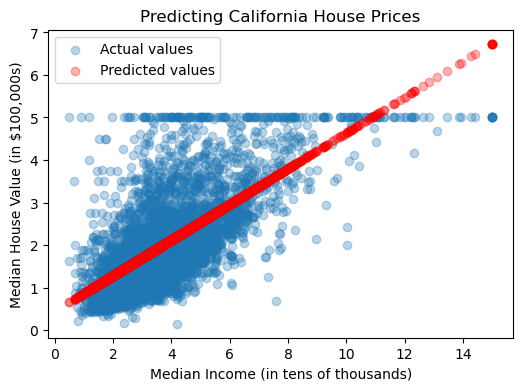

In [9]:
# We'll predict the median house value based on the median income.
# Median income (MedInc) is a good predictor and has a clear linear relationship.

X = df[['MedInc']]
y = df['MedHouseVal']

# Split data into training and test sets
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

# Train a simple Linear Regression model
model = LinearRegression()
model.fit(X_train, y_train)

# Make predictions
y_pred = model.predict(X_test)

# Evaluate performance
print("R² score:", round(r2_score(y_test, y_pred), 3))
print("Mean Squared Error:", round(mean_squared_error(y_test, y_pred), 3))

# Visualize the regression line
plt.figure(figsize=(6,4))
plt.scatter(X_test, y_test, alpha=0.3, label="Actual values")
plt.scatter(X_test, y_pred, color="red", alpha=0.3, label="Predicted values")
plt.xlabel("Median Income (in tens of thousands)")
plt.ylabel("Median House Value (in $100,000s)")
plt.title("Predicting California House Prices")
plt.legend()
plt.show()


In [8]:
X = df[['MedInc', 'AveRooms', 'HouseAge', 'AveOccup']]
y = df['MedHouseVal']

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

model = LinearRegression()
model.fit(X_train, y_train)
y_pred = model.predict(X_test)

print("R² score:", r2_score(y_test, y_pred))
print("Mean Squared Error:", mean_squared_error(y_test, y_pred))


R² score: 0.49828508595474386
Mean Squared Error: 0.6574517278822649


## 🌸 Example 2: Classifying Flowers (Classification)

This is an example of **classification** using the famous Iris dataset.

We'll use a decision tree to classify iris flowers based on petal and sepal dimensions.


As classification is a supervised task, and we are interested in how well the model generalises (i.e. predicts on new, unseen data), we split our data into a **training set**,
to build the model from, and a **test-set**, to evaluate how well our model performs on new data. 

The ``train_test_split`` function form the ``cross_validation`` module does that for us, by randomly splitting of 25% of the data for testing.

<img src="./figures/imgs/train_test_split.svg" width="80%">

In [ ]:
# import required libraries
from sklearn.datasets import load_iris
from sklearn.model_selection import train_test_split
from sklearn.tree import DecisionTreeClassifier
from sklearn.metrics import accuracy_score


In [ ]:
# Load data
iris = load_iris()
X = iris.data
y = iris.target

# Split into train/test

# Train a Decision Tree

# Predict

# Evaluate

In [ ]:
X.shape

(150, 4)

In [ ]:
iris.target_names

array(['setosa', 'versicolor', 'virginica'], dtype='<U10')

In [ ]:
y

array([0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0,
       0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0,
       0, 0, 0, 0, 0, 0, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1,
       1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1,
       1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2,
       2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2,
       2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2])

In [ ]:
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)



In [ ]:
X_train.shape

(120, 4)

In [ ]:
X_test.shape

(30, 4)

In [ ]:
clf = DecisionTreeClassifier()

clf.fit(X_train, y_train)

DecisionTreeClassifier()

In [ ]:
y_pred = clf.predict(X_test)

In [ ]:
y_pred

array([1, 0, 2, 1, 1, 0, 1, 2, 1, 1, 2, 0, 0, 0, 0, 1, 2, 1, 1, 2, 0, 2,
       0, 2, 2, 2, 2, 2, 0, 0])

In [ ]:
y_test

array([1, 0, 2, 1, 1, 0, 1, 2, 1, 1, 2, 0, 0, 0, 0, 1, 2, 1, 1, 2, 0, 2,
       0, 2, 2, 2, 2, 2, 0, 0])

In [ ]:
print(f"Accuracy: {accuracy_score(y_test, y_pred)}")

Accuracy: 1.0


## Summary

- Machine learning helps computers learn from data.
- Supervised learning uses labeled data to make predictions.
- We explored two simple examples:
  - Linear Regression to predict house prices
  - Decision Tree Classification to classify flowers

There’s much more to learn, but this gives you a taste of what ML can do!

---

## A Glimpse into Generative Models

In recent years, **generative models** have taken center stage in machine learning. These models are capable of creating new data — such as images, text, music, or even code — that resembles the data they were trained on.

### Large Language Models (LLMs)
Large Language Models like **ChatGPT** are a type of generative model trained on massive text datasets. They learn patterns in language and can:
- Generate human-like responses in conversation
- Write essays, summaries, or poems
- Translate languages
- Answer questions and assist with coding

These models fall under the broader category of **deep learning**, using neural networks with billions of parameters.

### Other Generative Models
- **GANs (Generative Adversarial Networks):** Used to create realistic images, art, and deepfakes.
- **VAEs (Variational Autoencoders):** Generate variations of input data, useful in image and audio synthesis.

Generative models represent a powerful and fast-evolving area of machine learning — showing that ML is not just about prediction, but also about creativity.
